In [118]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import ttest_1samp, ttest_ind

## Problem 1

## A wholesale distributor operating in different regions of Portugal has information on annual spending of several items in their stores across different regions and channels. The data (Wholesale Customer.csv) consists of 440 large retailers’ annual spending on 6 different varieties of products in 3 different regions (Lisbon, Oporto, Other) and across different sales channel (Hotel/Restaurant/Café HoReCa, Retail).

In [119]:
df1 = pd.read_csv('Wholesale Customer.csv')

## 1.1. Use methods of descriptive statistics to summarize data.

## Which Region and which Channel seems to spend more?
## Which Region and which Channel seems to spend less?

In [120]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 9 columns):
Buyer/Spender       440 non-null int64
Channel             440 non-null object
Region              440 non-null object
Fresh               440 non-null int64
Milk                440 non-null int64
Grocery             440 non-null int64
Frozen              440 non-null int64
Detergents_Paper    440 non-null int64
Delicatessen        440 non-null int64
dtypes: int64(7), object(2)
memory usage: 31.0+ KB


In [121]:
df1.describe(include='all')

,Buyer/Spender,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
count,440.000000,440,440,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
unique,NaN,2,3,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Hotel,Other,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,298,316,NaN,NaN,NaN,NaN,NaN,NaN
mean,220.500000,NaN,NaN,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,127.161315,NaN,NaN,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,NaN,NaN,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,110.750000,NaN,NaN,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,220.500000,NaN,NaN,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,330.250000,NaN,NaN,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000


In [122]:
df1.isnull().any().any()

False

## Ans : The above two outputs indicate the methods of descriptive statistics to summarize the data

In [123]:
df1['Total_Spendings'] = df1['Fresh']+df1['Milk']+df1['Grocery']+df1['Frozen']+df1['Detergents_Paper']+df1['Delicatessen']

In [124]:
df1.head()

,Buyer/Spender,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen,Total_Spendings
0,1,Retail,Other,12669,9656,7561,214,2674,1338,34112
1,2,Retail,Other,7057,9810,9568,1762,3293,1776,33266
2,3,Retail,Other,6353,8808,7684,2405,3516,7844,36610
3,4,Hotel,Other,13265,1196,4221,6404,507,1788,27381
4,5,Retail,Other,22615,5410,7198,3915,1777,5185,46100


In [125]:
df1.groupby('Channel')['Total_Spendings'].sum().nlargest(1)

Channel
Hotel    7999569
Name: Total_Spendings, dtype: int64

In [126]:
df1.groupby('Region')['Total_Spendings'].sum().nlargest(2)

Region
Other     10677599
Lisbon     2386813
Name: Total_Spendings, dtype: int64

In [127]:
df1.groupby('Channel').sum()['Total_Spendings'].nsmallest(1)

Channel
Retail    6619931
Name: Total_Spendings, dtype: int64

In [128]:
df1.groupby('Region').sum()['Total_Spendings'].nsmallest(1)

Region
Oporto    1555088
Name: Total_Spendings, dtype: int64

## Ans : From the above output, we can infer that:
## Region that spends more is 'Other', if we consider that 'Other' is a combination of multiple regions, then the region 'Lisbon' will be considered to be the region which spends more. 
## Channel that spends more is 'Hotel'
## Region that spends less is 'Oporto'
## Channel that spends less is 'Retail'

## 1.2. There are 6 different varieties of items are considered.
## Do all varieties show similar behaviour across Region and Channel?

To check the behavior of 6 different varities of items across Channel:

In [129]:
g1 = df1[df1.Channel=='Hotel']

In [130]:
g2 = df1[df1.Channel=='Retail']

To check the p_values of 6 different varities of items across Channel:

In [131]:
t_statistic_Fresh, p_value_Fresh = ttest_ind(g1['Fresh'], g2['Fresh'])
t_statistic_Milk, p_value_Milk = ttest_ind(g1['Milk'], g2['Milk'])
t_statistic_Grocery, p_value_Grocery = ttest_ind(g1['Grocery'], g2['Grocery'])
t_statistic_Frozen, p_value_Frozen = ttest_ind(g1['Frozen'], g2['Frozen'])
t_statistic_Detergents_Paper, p_value_Detergents_Paper = ttest_ind(g1['Detergents_Paper'], g2['Detergents_Paper'])
t_statistic_Delicatessen, p_value_Delicatessen = ttest_ind(g1['Delicatessen'], g2['Delicatessen'])

To check the behavior of 6 different varities of items across Region:

In [132]:
g3 = df1[df1.Region=='Oporto']

In [133]:
g4 = df1[df1.Region=='Lisbon']

In [134]:
g5 = df1[df1.Region=='Other']

To check the p_values of 6 different varities of items across Region:

In [135]:
t_statistic_Fresh_1_2, p_value_Fresh_1_2 = ttest_ind(g3['Fresh'], g4['Fresh'])
t_statistic_Fresh_2_3, p_value_Fresh_2_3 = ttest_ind(g4['Fresh'], g5['Fresh'])
t_statistic_Fresh_3_1, p_value_Fresh_3_1 = ttest_ind(g5['Fresh'], g3['Fresh'])

t_statistic_Milk_1_2, p_value_Milk_1_2 = ttest_ind(g3['Milk'], g4['Milk'])
t_statistic_Milk_2_3, p_value_Milk_2_3 = ttest_ind(g4['Milk'], g5['Milk'])
t_statistic_Milk_3_1, p_value_Milk_3_1 = ttest_ind(g5['Milk'], g3['Milk'])

t_statistic_Grocery_1_2, p_value_Grocery_1_2 = ttest_ind(g3['Grocery'], g4['Grocery'])
t_statistic_Grocery_2_3, p_value_Grocery_2_3 = ttest_ind(g4['Grocery'], g5['Grocery'])
t_statistic_Grocery_3_1, p_value_Grocery_3_1 = ttest_ind(g5['Grocery'], g3['Grocery'])

t_statistic_Frozen_1_2, p_value_Frozen_1_2 = ttest_ind(g3['Frozen'], g4['Frozen'])
t_statistic_Frozen_2_3, p_value_Frozen_2_3 = ttest_ind(g4['Frozen'], g5['Frozen'])
t_statistic_Frozen_3_1, p_value_Frozen_3_1 = ttest_ind(g5['Frozen'], g3['Frozen'])

t_statistic_Detergents_Paper_1_2, p_value_Detergents_Paper_1_2 = ttest_ind(g3['Detergents_Paper'], g4['Detergents_Paper'])
t_statistic_Detergents_Paper_2_3, p_value_Detergents_Paper_2_3 = ttest_ind(g4['Detergents_Paper'], g5['Detergents_Paper'])
t_statistic_Detergents_Paper_3_1, p_value_Detergents_Paper_3_1 = ttest_ind(g5['Detergents_Paper'], g3['Detergents_Paper'])

t_statistic_Delicatessen_1_2, p_value_Delicatessen_1_2 = ttest_ind(g3['Delicatessen'], g4['Delicatessen'])
t_statistic_Delicatessen_2_3, p_value_Delicatessen_2_3 = ttest_ind(g4['Delicatessen'], g5['Delicatessen'])
t_statistic_Delicatessen_3_1, p_value_Delicatessen_3_1 = ttest_ind(g5['Delicatessen'], g3['Delicatessen'])


Creating a table of p_values of 6 different varities across Channels and Regions:

In [136]:
p_values = [[p_value_Fresh,p_value_Milk,p_value_Grocery,p_value_Frozen,p_value_Detergents_Paper,p_value_Delicatessen],
            [p_value_Fresh_1_2,p_value_Milk_1_2,p_value_Grocery_1_2,p_value_Frozen_1_2,p_value_Detergents_Paper_1_2,p_value_Delicatessen_1_2],
            [p_value_Fresh_2_3,p_value_Milk_2_3,p_value_Grocery_2_3,p_value_Frozen_2_3,p_value_Detergents_Paper_2_3,p_value_Delicatessen_2_3],
            [p_value_Fresh_3_1,p_value_Milk_3_1,p_value_Grocery_3_1,p_value_Frozen_3_1,p_value_Detergents_Paper_3_1,p_value_Delicatessen_3_1]
           ]

In [137]:
columns = ['Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicatessen']
index = ['Hotel and Retail','Oporto and Lisbon','Lisbon and Other','Other and Oporto']

In [138]:
p_values_df = pd.DataFrame(p_values,columns=columns,index=index)
p_values_df

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
Hotel and Retail,0.000365,1.664946e-24,5.695745e-46,0.000020,2.954117e-51,0.241003
Oporto and Lisbon,0.532423,7.089756e-01,3.013575e-01,0.358619,2.837094e-01,0.397729
Lisbon and Other,0.388637,6.095534e-01,6.780835e-01,0.914015,7.719480e-01,0.480628
Other and Oporto,0.189029,4.606695e-01,3.844887e-01,0.172305,2.550678e-01,0.333255


## Hypothesis Testing:
## Null Hypothesis : The variables show similar behavior across Channels and Regions.
## Alternate Hypothesis : The variables do not show similar behavior across Channels and Regions.

## Assuming alpha is 0.1 (Confidence interval of 90%) 

In [139]:
p_values_df<0.1

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
Hotel and Retail,True,True,True,True,True,False
Oporto and Lisbon,False,False,False,False,False,False
Lisbon and Other,False,False,False,False,False,False
Other and Oporto,False,False,False,False,False,False


## Ans : From the above p_value table, we can infer that:

##        1) Only the variable 'Delicatessen' shows a similar behavior across both the Channels (Hotel and Retail)
##        2) All 6 variables 'Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicatessen' show a similar behavior across all regions ( Oporto, Lisbon, Other)

## Assuming alpha is 0.05 (Confidence interval of 95%) 

In [140]:
p_values_df<0.05

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
Hotel and Retail,True,True,True,True,True,False
Oporto and Lisbon,False,False,False,False,False,False
Lisbon and Other,False,False,False,False,False,False
Other and Oporto,False,False,False,False,False,False


## Ans : From the above p_value table, we can infer that:
##        1) Only the variable 'Delicatessen' shows a similar behavior across both the Channels (Hotel and Retail)
##        2) All 6 variables 'Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicatessen' show a similar behavior across all regions ( Oporto, Lisbon, Other)

## Assuming alpha is 0.01 (Confidence interval of 99%) 

In [141]:
p_values_df<0.01

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
Hotel and Retail,True,True,True,True,True,False
Oporto and Lisbon,False,False,False,False,False,False
Lisbon and Other,False,False,False,False,False,False
Other and Oporto,False,False,False,False,False,False


## Ans : From the above p_value table, we can infer that:
##        1) Only the variable 'Delicatessen' shows a similar behavior across both the Channels (Hotel and Retail)
##        2) All 6 variables 'Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicatessen' show a similar behavior across all regions ( Oporto, Lisbon, Other)

## 1.3. On the basis of the descriptive measure of variability, which item shows the most inconsistent behaviour?
## Which items shows the least inconsistent behaviour?

In order to study the behavior of 6 Variables ('Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicatessen') only, dropping the Column variables 'Buyer/Spender' and 'Total_Spendings'

In [142]:
df_new = df1.drop(['Buyer/Spender','Total_Spendings'], axis=1)

In [143]:
df_new.std()/df_new.mean()

Fresh               1.053918
Milk                1.273299
Grocery             1.195174
Frozen              1.580332
Detergents_Paper    1.654647
Delicatessen        1.849407
dtype: float64

## Ans : From the above table, we can infer that :
##        1) The variable 'Delicatessen' shows most inconsistent behaviour. 
##        2) The variable 'Fresh' shows least inconsistent behaviour.

## 1.4. Are there any outliers in the data?

(array([1, 2, 3, 4, 5, 6]), <a list of 6 Text xticklabel objects>)

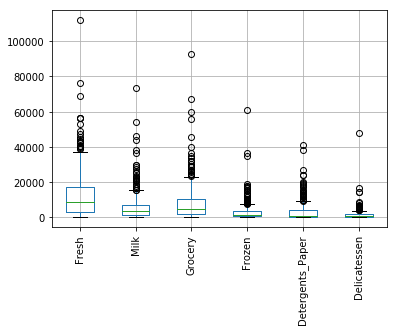

In [179]:
df1.drop(['Buyer/Spender', 'Total_Spendings'], axis = 1).boxplot()
plt.xticks(rotation=90)

## Ans : From the above boxplot, we can infer that all the variables have outliers.

## 1.5. On the basis of this report, what are the recommendations?

## Ans : From the descriptive statistics we can infer that 
## 1) The data is inconsistent, as they do not vary evenly about its mean.
## 2) From the p_value table, we can see that all the variables show similar behavior across all the regions, however, most of the variables do not have a similar behavior across the Channel, except Delicatessen.So, it is very important and vital for the company to investigate the behavior across channels.
## 3) Further attempt should be made to separate out and clearly define the term 'Other' in order to provide improved results so as obtain a better study.
## 4) It is recommended that the instruments for conducting the investigation be improved and made more reliable.
## 5) There is the need to ensure that the various items in the dimensions are re-visited and re-tested for relaibility. 

## Problem 2

## The Student News Service at Clear Mountain State University (CMSU) has decided to gather data about the undergraduate students that attend CMSU. CMSU creates and distributes a survey of 14 questions and receives responses from 62 undergraduates (stored in the Survey.csv file).

In [145]:
df2 = pd.read_csv('Survey-1.csv')

In [146]:
df2.head()

,ID,Gender,Age,Class,Major,Grad Intention,GPA,Employment,Salary,Social Networking,Satisfaction,Spending,Computer,Text Messages
0,1,Female,20,Junior,Other,Yes,2.9,Full-Time,50.0,1,3,350,Laptop,200
1,2,Male,23,Senior,Management,Yes,3.6,Part-Time,25.0,1,4,360,Laptop,50
2,3,Male,21,Junior,Other,Yes,2.5,Part-Time,45.0,2,4,600,Laptop,200
3,4,Male,21,Junior,CIS,Yes,2.5,Full-Time,40.0,4,6,600,Laptop,250
4,5,Male,23,Senior,Other,Undecided,2.8,Unemployed,40.0,2,4,500,Laptop,100


In [147]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 14 columns):
ID                   62 non-null int64
Gender               62 non-null object
Age                  62 non-null int64
Class                62 non-null object
Major                62 non-null object
Grad Intention       62 non-null object
GPA                  62 non-null float64
Employment           62 non-null object
Salary               62 non-null float64
Social Networking    62 non-null int64
Satisfaction         62 non-null int64
Spending             62 non-null int64
Computer             62 non-null object
Text Messages        62 non-null int64
dtypes: float64(2), int64(6), object(6)
memory usage: 6.9+ KB


In [148]:
df2.describe(include='all')

,ID,Gender,Age,Class,Major,Grad Intention,GPA,Employment,Salary,Social Networking,Satisfaction,Spending,Computer,Text Messages
count,62.000000,62,62.000000,62,62,62,62.000000,62,62.000000,62.000000,62.000000,62.000000,62,62.000000
unique,NaN,2,NaN,3,8,3,NaN,3,NaN,NaN,NaN,NaN,3,NaN
top,NaN,Female,NaN,Senior,Retailing/Marketing,Yes,NaN,Part-Time,NaN,NaN,NaN,NaN,Laptop,NaN
freq,NaN,33,NaN,31,14,28,NaN,43,NaN,NaN,NaN,NaN,55,NaN
mean,31.500000,NaN,21.129032,NaN,NaN,NaN,3.129032,NaN,48.548387,1.516129,3.741935,482.016129,NaN,246.209677
std,18.041619,NaN,1.431311,NaN,NaN,NaN,0.377388,NaN,12.080912,0.844305,1.213793,221.953805,NaN,214.465950
min,1.000000,NaN,18.000000,NaN,NaN,NaN,2.300000,NaN,25.000000,0.000000,1.000000,100.000000,NaN,0.000000
25%,16.250000,NaN,20.000000,NaN,NaN,NaN,2.900000,NaN,40.000000,1.000000,3.000000,312.500000,NaN,100.000000
50%,31.500000,NaN,21.000000,NaN,NaN,NaN,3.150000,NaN,50.000000,1.000000,4.000000,500.000000,NaN,200.000000
75%,46.750000,NaN,22.000000,NaN,NaN,NaN,3.400000,NaN,55.000000,2.000000,4.000000,600.000000,NaN,300.000000


In [149]:
df2.isnull().any().any()

False

## Part I

## 2.1. For this data, construct the following contingency tables (Keep Gender as row variable)

## 2.1.1. Gender and Major

In [150]:
data_crosstab1 = pd.crosstab(df2['Gender'],df2['Major'],margins = False) 
data_crosstab1

Major,Accounting,CIS,Economics/Finance,International Business,Management,Other,Retailing/Marketing,Undecided
Gender,,,,,,,,
Female,3,3,7,4,4,3,9,0
Male,4,1,4,2,6,4,5,3


## Ans : The above output shows the contingency table between Gender and Major

## 2.1.2. Gender and Grad Intention

In [151]:
data_crosstab2 = pd.crosstab(df2['Gender'], df2['Grad Intention'], margins = False) 
data_crosstab2

Grad Intention,No,Undecided,Yes
Gender,,,
Female,9,13,11
Male,3,9,17


## Ans : The above output shows the contingency table between Gender and Grad Intention

## 2.1.3. Gender and Employment

In [152]:
data_crosstab3 = pd.crosstab(df2['Gender'],df2['Employment'], margins = False) 
data_crosstab3

Employment,Full-Time,Part-Time,Unemployed
Gender,,,
Female,3,24,6
Male,7,19,3


## Ans : The above output shows the contingency table between Gender and Employment

## 2.1.4. Gender and Computer

In [153]:
data_crosstab4 = pd.crosstab(df2['Gender'],df2['Computer'],margins = False) 
data_crosstab4

Computer,Desktop,Laptop,Tablet
Gender,,,
Female,2,29,2
Male,3,26,0


## Ans : The above output shows the contingency table between Gender and Computer

## 2.2. Assume that the sample is a representative of the population of CMSU. Based on the data, answer the following questions:

## 2.2.1. What is the probability that a randomly selected CMSU student will be male?
## What is the probability that a randomly selected CMSU student will be female?

In [154]:
df2.Gender.value_counts()

Female    33
Male      29
Name: Gender, dtype: int64

In [155]:
total_students = 62
no_of_male = 29
no_of_female = 33

prob_of_male = no_of_male/total_students
prob_of_female = no_of_female/total_students
print(prob_of_male , prob_of_female)

0.46774193548387094 0.532258064516129


## Ans : The probability that a randomly selected CMSU student will be male : 0.467,
##       The probability that a randomly selected CMSU student will be female : 0.532.

## 2.2.2. Find the conditional probability of different majors among the male students in CMSU.
## Find the conditional probability of different majors among the female students of CMSU.

In [156]:
t1_cp_major_male = (data_crosstab1[1:]/no_of_male)*100
t1_cp_major_male

Major,Accounting,CIS,Economics/Finance,International Business,Management,Other,Retailing/Marketing,Undecided
Gender,,,,,,,,
Male,13.793103,3.448276,13.793103,6.896552,20.689655,13.793103,17.241379,10.344828


In [157]:
t2_cp_major_female = (data_crosstab1[0:1]/no_of_female)*100
t2_cp_major_female

Major,Accounting,CIS,Economics/Finance,International Business,Management,Other,Retailing/Marketing,Undecided
Gender,,,,,,,,
Female,9.090909,9.090909,21.212121,12.121212,12.121212,9.090909,27.272727,0.0


## Ans :
## t1_cp_major_male indicates the conditional probability of different majors among the male students (in %)
## t2_cp_major_female indicates the conditional probability of different majors among the female students in CMSU (in %)

## 2.2.3. Find the conditional probability of intent to graduate, given that the student is a male.
## Find the conditional probability of intent to graduate, given that the student is a female.

In [158]:
t1_cp_grad_male = (data_crosstab2[1:]/no_of_male)*100
t1_cp_grad_male

Grad Intention,No,Undecided,Yes
Gender,,,
Male,10.344828,31.034483,58.62069


In [159]:
t2_cp_grad_female = (data_crosstab2[0:1]/no_of_female)*100
t2_cp_grad_female

Grad Intention,No,Undecided,Yes
Gender,,,
Female,27.272727,39.393939,33.333333


## Ans :
## t1_cp_grad_male indicates the conditional probability of intent to graduate, given that the student is a male (in %)
## t2_cp_grad_female indicates the conditional probability of intent to graduate, given that the student is a female (in %)

## 2.2.4. Find the conditional probability of employment status for the male students as well as for the female students.

In [160]:
t1_cp_empstat_male = (data_crosstab3[1:]/no_of_male)*100
t1_cp_empstat_male

Employment,Full-Time,Part-Time,Unemployed
Gender,,,
Male,24.137931,65.517241,10.344828


In [161]:
t2_cp_empstat_female = (data_crosstab3[0:1]/no_of_female)*100
t2_cp_empstat_female

Employment,Full-Time,Part-Time,Unemployed
Gender,,,
Female,9.090909,72.727273,18.181818


## Ans :
## t1_cp_empstat_male indicates the conditional probability of employment status for the male students (in %)
## t2_cp_empstat_female indicates the conditional probability of employment status for the female students (in %)

## 2.2.5. Find the conditional probability of laptop preference among the male students as well as among the female students.

In [162]:
t1_cp_laptop_pref_male = (data_crosstab4[1:]['Laptop']/no_of_male)*100
t1_cp_laptop_pref_male

Gender
Male    89.655172
Name: Laptop, dtype: float64

In [163]:
t2_cp_laptop_pref_female = (data_crosstab4[0:1]['Laptop']/no_of_female)*100
t2_cp_laptop_pref_female

Gender
Female    87.878788
Name: Laptop, dtype: float64

## Ans :
## t1_cp_laptop_pref_male indicates the conditional probability of laptop preference among the male students (in %)
## t2_cp_laptop_pref_female indicates the conditional probability of laptop preference among the female students (in %)

## 2.3. Based on the above probabilities, do you think that the column variable in each case is independent of Gender?
## Justify your comment in each case.

## Ans : To study if each variable is independent of Gender, let us perform Chi Square Test in order to obtain the results.

In [164]:
from scipy.stats import chi2_contingency
from scipy.stats import chi2

## Case 1 : Gender and Major

In [165]:
stats.chi2_contingency(data_crosstab1)

(7.084844866036089,
 0.42009968345511806,
 7,
 array([[3.72580645, 2.12903226, 5.85483871, 3.19354839, 5.32258065,
         3.72580645, 7.4516129 , 1.59677419],
        [3.27419355, 1.87096774, 5.14516129, 2.80645161, 4.67741935,
         3.27419355, 6.5483871 , 1.40322581]]))

## Ans : From the above output, we can infer that the p_value is 42.00%. 
## Hence the Column Variable 'Major' is independent of Gender at alpha = 0.01, 0.05, 0.1( Confidence interval = 99%, 95%, 90%)

## Case 2 : Gender and Grad Intention

In [166]:
stats.chi2_contingency(data_crosstab2)

(4.774796781066374,
 0.09186837889149435,
 2,
 array([[ 6.38709677, 11.70967742, 14.90322581],
        [ 5.61290323, 10.29032258, 13.09677419]]))

## Ans : From the above output, we can infer that the p_value is 9.18%, 
## Hence the Column Variable 'Grad Intent' is independent of Gender at alpha = 0.01, 0.05( Confidence interval = 99%, 95%) and 
## Column Variable 'Grad Intent' is dependent of Gender at alpha = 0.1( Confidence interval = 90%)

## Case 3 : Gender and Employment

In [167]:
stats.chi2_contingency(data_crosstab3)

(2.9355495613715337,
 0.2304376894892966,
 2,
 array([[ 5.32258065, 22.88709677,  4.79032258],
        [ 4.67741935, 20.11290323,  4.20967742]]))

## Ans : From the above output, we can infer that the p_value is 23.04%. 
## Hence the Column Variable 'Employment' is independent of Gender at alpha = 0.01, 0.05, 0.1( Confidence interval = 99%, 95%, 90%)

## Case 4 : Gender and Computer

In [168]:
stats.chi2_contingency(data_crosstab4)

(2.114372565783224,
 0.3474320117040881,
 2,
 array([[ 2.66129032, 29.27419355,  1.06451613],
        [ 2.33870968, 25.72580645,  0.93548387]]))

## Ans : From the above output, we can infer that the p_value is 34.74%.
## Hence the Column Variable 'Computer' is independent of Gender at alpha = 0.01, 0.05, 0.1( Confidence interval = 99%, 95%, 90%)

## Part II

## 2.4. Note that there are three numerical (continuous) variables in the data set, Salary, Spending and Text Messages. For each of them comment whether they follow a normal distribution.
## Write a note summarizing your conclusions.
## [Recall that symmetric histogram does not necessarily mean that the underlying distribution is symmetric]

In [169]:
stats.normaltest(df2['Salary'])

NormaltestResult(statistic=3.84580947969415, pvalue=0.14618172494628334)

In [170]:
stats.normaltest(df2['Spending'])

NormaltestResult(statistic=30.49562450314631, pvalue=2.387587398454289e-07)

In [171]:
stats.normaltest(df2['Text Messages'])

NormaltestResult(statistic=16.34755294390911, pvalue=0.0002819512224692029)

## Ans : Assuming a confidence interval of 95% at alpha = 0.05, 
##         Null hypothesis : the variables show normal distribution
##         Alternate hypothesis : the variables do not show normal distribution
## from the above code, we can infer that:
##       1) The p_value of the variable 'Salary' is 14.6% (High) which is greater than alpha = 5%, hence the null hypothesis that the variable 'Salary' has a normal distribution is accpeted.
##       2) The p_value of the variable 'Spending' is 0.0000238 % (Very Low)  which is lesser than alpha = 5%, hence the null hypothesis that the variable 'Spendings' has a normal distribution is rejected.
##       3) The p_value of the variable 'Text Messages' is 0.028 % (Low) which is lesser than alpha = 5%, hence the null hypothesis that the variable 'Text Messages' has a normal distribution is rejected.

## Problem 3

## An important quality characteristic used by the manufacturers of ABC asphalt shingles is the amount of moisture the shingles contain when they are packaged. Customers may feel that they have purchased a product lacking in quality if they find moisture and wet shingles inside the packaging.   In some cases, excessive moisture can cause the granules attached to the shingles for texture and colouring purposes to fall off the shingles resulting in appearance problems. To monitor the amount of moisture present, the company conducts moisture tests. A shingle is weighed and then dried. The shingle is then reweighed, and based on the amount of moisture taken out of the product, the pounds of moisture per 100 square feet is calculated. The company claims that the mean moisture content cannot be greater than 0.35 pound per 100 square feet.
## The file (A & B shingles.csv) includes 36 measurements (in pounds per 100 square feet) for A shingles and 31 for B shingles.

In [172]:
df3 = pd.read_csv('A & B shingles-1.csv')

In [173]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 2 columns):
A    36 non-null float64
B    31 non-null float64
dtypes: float64(2)
memory usage: 656.0 bytes


In [174]:
df3.describe(include='all')

,A,B
count,36.000000,31.000000
mean,0.316667,0.273548
std,0.135731,0.137296
min,0.130000,0.100000
25%,0.207500,0.160000
50%,0.290000,0.230000
75%,0.392500,0.400000
max,0.720000,0.580000


In [175]:
df3.isnull().sum()

A    0
B    5
dtype: int64

## 3.1. For the A shingles, form the null and alternative hypothesis to test whether the population mean moisture content is less than 0.35 pound per 100 square feet.

In [176]:
t_stat_A, p_value_A = stats.ttest_1samp(df3['A'],0.35)
t_stat_A, p_value_A

(-1.4735046253382782, 0.14955266289815025)

## Ans : 
## The null hypothesis : The population mean moisture content is greater than or equal to 0.35 pound per 100 square feet.
## The alternate hypothesis : The population mean moisture content is less than 0.35 pound per 100 square feet.

## From the above output, we can infer that :
## The p_value is 14.95% which is greater than alpha = 0.01,0.05,0.1(confidence interval of 90%,95%,99%). Hence the null hypothesis that the population mean moisture content is greater than or equal to 0.35 pound per 100 square feet is accpeted (ie., we fail to reject the null hypothesis).

## Hence the population mean moisture content for A Shingles is greater than or equal to 0.35 pound per 100 square feet.

## 3.2. For the B shingles, form the null and alternative hypothesis to test whether the population mean moisture content is less than 0.35 pound per 100 square feet.

In [177]:
t_stat_B, p_value_B = stats.ttest_1samp(df3['B'].dropna(),0.35)
t_stat_B, p_value_B

(-3.1003313069986995, 0.004180954800638363)

## Ans : 
## The null hypothesis : The population mean moisture content is greater than or equal to 0.35 pound per 100 square feet.
## The alternate hypothesis : The population mean moisture content is less than 0.35 pound per 100 square feet.

## From the above output, we can infer that :
## The p_value is 0.41% which is lesser than alpha = 0.01,0.05,0.1(confidence interval of 90%,95%,99%). Hence the null hypothesis that the population mean moisture content is greater than or equal to 0.35 pound per 100 square feet is rejected.

## Hence the population mean moisture content for B Shingles is less than 0.35 pound per 100 square feet.

## 3.3. Do you think that the population means for shingles A and B are equal?
## Form the hypothesis and conduct the test of the hypothesis.
## What assumption do you need to check before the test for equality of means is performed?

In [178]:
t_stat, p_value = stats.ttest_ind(df3['A'],df3['B'].dropna())
t_stat, p_value

(1.289628271966112, 0.2017496571835328)

## Ans:
    
## Assumptions to be made:
## 1) Data is continuous.
## 2) The data variables follow a normal distribution. By this, we specify the alpha level, level of significance, p_value as a selection criteria for acceptance or rejection.
## 3) Sample size is reasonably large enough to perform the hypothesis tests.
## 4) Samples we have from the population is completely random.
## 5) The samples in Shingles and in Shingles B are independent of each other.
    
## Let us assume alpha = 0.05

## Test of Hypothesis:
## Null Hypothesis : Population mean of shingles A is equal to the Population mean of Shingles B.
## Alternate Hypothesis: Population mean of shingles A is not equal to the Population mean of Shingles B.


## Conclusion:
## From the output :we see that the P value is 20.17%, which is greater than alpha value. Therefore, we fail to reject the null hypothesis.

## Hence, the population mean for Shingles A is equal to the population mean of Shingles B.

## 3.4. What assumption about the population distribution is needed in order to conduct the hypothesis tests above?

## Ans :

## Assumptions about population distribution that are required in order to conduct hypothesis tests are :
## 1) Data is continuous.
## 2) The data variables follow a normal distribution. 

## Assumptions about sample distribution that are required in order to conduct hypothesis tests are :
## 1) Sample size is reasonably large enough to perform the hypothesis tests.
## 2) Samples we have from the population is completely random.
## 3) The samples in Shingles and in Shingles B are independent of each other.